## Learning Structure in AMD Stock Time Series Using Machine Learning

### Abstract

Financial time-series data are a central example of high-dimensional, noisy, and non-stationary data, making them an important testbed for modern machine learning methods. Understanding patterns in stock price dynamics is relevant for prediction, representation learning, and uncertainty quantification. In this project, I will analyze historical data from a single stock, Advanced Micro Devices (AMD), and use it as a case study to apply a range of machine learning techniques covered in this course.

The dataset consists of daily AMD stock observations, including adjusted closing price (USD) and derived features such as log returns, moving averages, and rolling volatility. These features allow us to capture both long-term trends and short-term fluctuations in the data. We begin with baseline models such as linear regression and regularized regression, directly connecting to course topics on linear models, matrix methods, and model fitting.

Then extending to nonlinear models, including multi-layer perceptrons trained using stochastic gradient descent and adaptive optimizers such as Adam, following topics on neural networks and optimization. In addition, I will be exploring unsupervised learning methods, including principal component analysis (PCA) and K-means clustering, to identify lower-dimensional structure and potential regimes in the time series. These steps relate to course topics on dimensionality reduction, feature learning, and unsupervised methods.

(Placeholder)
Preliminary results suggest that some features (denoted X), such as recent price trends or volatility, may contain useful information for predicting short-term stock movements, while other features (denoted Y) appear less informative.

Overall, this project will apply multiple concepts from the course, including regression, neural networks, optimization, and unsupervised learning, to a real-world time-series dataset.

[*********************100%***********************]  1 of 1 completed


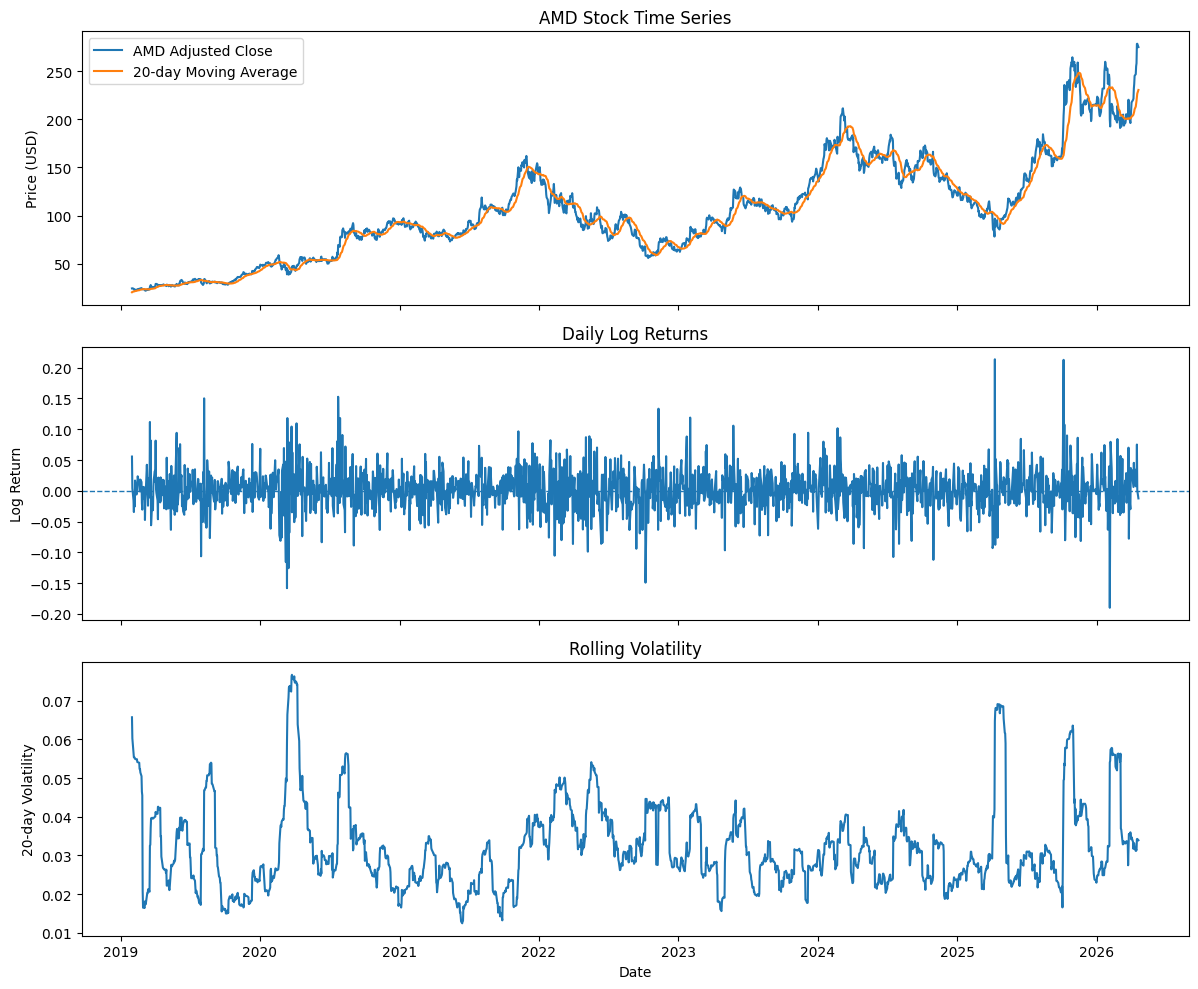

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

ticker = "AMD"
start_date = "2019-01-01"
end_date = "2026-04-21"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

# If yfinance version returns multi-index columns, flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only useful columns
df = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].copy()


# Daily simple return
df['Return'] = df['Adj Close'].pct_change()

# Daily log return
df['LogReturn'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# 20-day moving average
df['MA20'] = df['Adj Close'].rolling(window=20).mean()

# 20-day rolling volatility of log returns
df['Volatility20'] = df['LogReturn'].rolling(window=20).std()

# Drop NaN rows created by rolling windows
df_clean = df.dropna().copy()


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Adjusted close price
axes[0].plot(df_clean.index, df_clean['Adj Close'], label='AMD Adjusted Close')
axes[0].plot(df_clean.index, df_clean['MA20'], label='20-day Moving Average')
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("AMD Stock Time Series")
axes[0].legend()


# Panel 2: Daily log returns
axes[1].plot(df_clean.index, df_clean['LogReturn'])
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_ylabel("Log Return")
axes[1].set_title("Daily Log Returns")

# Panel 3: Rolling volatility
axes[2].plot(df_clean.index, df_clean['Volatility20'])
axes[2].set_ylabel("20-day Volatility")
axes[2].set_xlabel("Date")
axes[2].set_title("Rolling Volatility")


plt.tight_layout()
plt.show()

fig.savefig("amd_figure1.png", dpi=300, bbox_inches="tight")